In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from graphviz import Digraph


In [8]:
import torch


In [9]:
def f(x):
    return 3*x**2 - 4*x + 5

In [10]:
f(2)

9

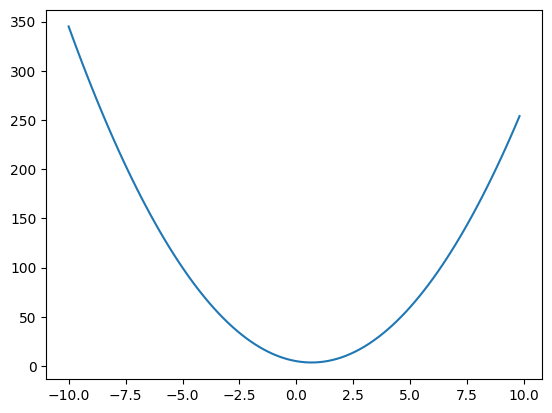

In [11]:
xs = np.arange(-10, 10, 0.2)
ys = f(xs)
plt.plot(xs, ys)

### Definition of the Derivative

The derivative of a function $f(x)$ at a point $x = a$ is defined as

$$
f'(a) = \lim_{h \to 0} \frac{f(a + h) - f(a)}{h}.
$$

If this limit exists, $f$ is differentiable at $a$.

More generally, the derivative function is

$$
f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{(x+h) - x}.
$$

Or:

$$
f'(x) = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}.
$$


In [12]:
h = 0.0001
x = 5
f(x)

60

In [13]:
f(x+h)

60.002600029999996

In [14]:
(f(x + h) - f(x)) / h # the slope of the function at x = 5

26.000299999964227

In [15]:
h = 0.0001
x = -5
f(x)

100

In [16]:
(f(x + h) - f(x)) / h

-33.99969999989594

In [17]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

print(d)

4.0


In [18]:
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c


In [19]:
h = 0.00001

a = 2.0
a += h # bump a by h

b = -3.0
c = 10.0

# 2.00001 * (-3) + 10 = 3.999
d2 = a*b + c # the new value for the function after bumping a by h

print(f"d1: {d1}")
print(f"d2: {d2}")
print(f"slope: {(d2 - d1) / h}")

d1: 4.0
d2: 3.9999699999999994
slope: -3.000000000064062


In [20]:
h = 0.00001

a = 2.0
b = -3.0
c = 10.0

b += h # bump b by h

d2 = a*b + c # the new value for the function after bumping a by h

print(f"d1: {d1}")
print(f"d2: {d2}")
print(f"slope: {(d2 - d1) / h}")

d1: 4.0
d2: 4.00002
slope: 2.0000000000131024


In [21]:
# we want the derivative of d wrt a, b, c
# dd/da = b
# dd/db = a
# dd/dc = 1

h = 0.00001

a = 2.0
b = -3.0
c = 10.0

c += h # bump b by h

d2 = a*b + c # the new value for the function after bumping a by h

print(f"d1: {d1}")
print(f"d2: {d2}")
print(f"slope: {(d2 - d1) / h}")

d1: 4.0
d2: 4.00001
slope: 0.9999999999621422


# creating the Value class
### to track and maintain the massive math expressions used in NNs

In [22]:
# import numpy as np
# # a = Value(2, label=a, oper=)
# class Value2:
#     def __init__(self, data, label='', _op='', _children=()):
#         self.data = data
#         self.label = label
#         self._op = _op
#         self._prev = set(_children)
#         self.grad = 0.0
#         self._backward = lambda: None
    
#     def __repr__(self):
#         return f"Value(data={self.data}, label={self.label})"
    
#     def __add__(self, other):
#         out = Value2(self.data + other.data, 'out', '+', (self, other))
        
#         def _backward():
#             self.grad += 1.0 * out.grad
#             other.grad += 1.0 * out.grad
        
#         out._backward = _backward
            
#         return out
    
#     def __mul__(self, other):
#         out = Value2(self.data * other.data, 'out', '*', (self, other))
        
#         def _backward():
#             self.grad += other.data * out.grad
#             self.grad += self.data  * out.grad
        
#         out._backward = _backward
#         return out
    
#     def __rmul__(self, other):
#         return self * other
    
#     def __neg__(self):
#         return (-1) * self
    
#     def __sub__(self, other):
#         return self + (-other)
    
#     def expo(self):
#         x = self.data
#         out = Value2(np.exp(x), '', 'exp', (self, ))
#         return out
    
#     def __pow__(self, other):
#         assert isinstance(other, (int, float))
#         out = Value2(self.data**other)
    
#     def __truediv__(self, other):
#         return self * other**-1
    
#     def tanh(self):
#         # a = value(3); tanh(a) = tanh(3)
#         x = self.data
#         t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
#         out = Value2(t, '', 'tanh', (self, ))
#         return out
    

    
    

This is an excellent piece of code. It looks like you are building a scalar auto-differentiation engine from scratch (very similar to Andrej Karpathy's `micrograd`). It is a fantastic way to understand how neural networks backpropagate gradients under the hood.

To understand why this code is written the way it is, we need to unpack **closures**. In this architecture, closures are the exact mechanism that allows the computational graph to "remember" how to calculate its derivatives long after the forward math has finished.

Here is a detailed breakdown of what closures are, how they work, and why they are the perfect tool for your `Value` class.

---

### What is a Closure in Python?

At its core, a **closure** is a record that stores a function together with an environment. 

In simpler terms: A closure is a nested function that "remembers" the values of the variables in its enclosing scope, **even after the outer function has finished executing.**

For a closure to exist in Python, three things must happen:
1.  You must have a nested function (a function defined inside another function).
2.  The nested function must refer to a value defined in the enclosing function.
3.  The enclosing function must return the nested function, or assign it to a variable that lives outside the function (so it survives after the outer function completes).

#### A Simple Example to Isolate the Concept

Let's look at a basic example before diving back into your neural network code:

```python
def make_multiplier(multiplier_value):
    # This is the enclosing scope. 
    # multiplier_value is a local variable here.
    
    def inner_function(number):
        # This is the nested function.
        # It uses 'multiplier_value' from the enclosing scope.
        return number * multiplier_value
        
    # We return the inner function itself, not the result of calling it.
    return inner_function

# We call the outer function. It creates an inner function 
# where multiplier_value is locked in as 5.
multiply_by_5 = make_multiplier(5)

# At this point, `make_multiplier` has finished executing. 
# Its local scope should technically be destroyed. But...

print(multiply_by_5(10)) 
# Output: 50
```

Notice what happened: When we call `multiply_by_5(10)`, the `make_multiplier` function has already finished running. Yet, `inner_function` magically remembers that `multiplier_value` was `5`. 

That is the closure. Python bundled the `inner_function` together with the state of `multiplier_value` at the time it was created, keeping it alive in memory.

---

### Why You Used Closures in Your `Value` Class

In your auto-differentiation engine, you are doing a "forward pass" (calculating the math) and building a computational graph at the exact same time. 

Later, you call `backward()`, which walks through that graph in reverse, calculating derivatives using the Chain Rule. 

Let's look at your multiplication method:

```python
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        # --- THE CLOSURE BEGINS HERE ---
        def _backward():
            self.grad  += out.grad * other.data
            other.grad += out.grad * self.data
        # --- THE CLOSURE ENDS HERE ---
        
        out._backward = _backward # Attaching it to the output node
        return out
```

#### The Timeline of Execution

**1. The Forward Pass (The Setup)**
Imagine you write `c = a * b` in your code (where `a` and `b` are `Value` objects). 
Python calls `a.__mul__(b)`. 
Inside `__mul__`, it calculates the forward pass: `self.data * other.data` and creates the `out` node. 

**2. The Problem: Remembering the Past**
To do backpropagation later, we need to apply the local derivative. For multiplication, the local derivatives are $\frac{\partial \text{out}}{\partial \text{self}} = \text{other.data}$ and $\frac{\partial \text{out}}{\partial \text{other}} = \text{self.data}$.

But here is the catch: when `c.backward()` is called way at the end of your script, the `__mul__` function has been dead and gone for a long time. How can the program possibly remember exactly which `self`, which `other`, and which `out` were involved in that specific multiplication?

**3. The Solution: The Closure**
You define `_backward()` *inside* `__mul__`. Inside `_backward()`, you use the variables `self`, `other`, and `out`. 

By assigning `out._backward = _backward`, you are saving that nested function onto the `out` object. Because `_backward()` references `self`, `other`, and `out`, Python creates a closure. It takes the exact instances of those variables that existed at that precise moment in time and "freezes" them inside `_backward()`.

#### What it looks like under the hood:

When you finally call `c.backward()`, it loops through the graph and eventually calls `c._backward()`. 
Because of the closure, `_backward()` wakes up and says:
* *"I remember `out`! It was the `Value` object representing `c`."*
* *"I remember `self`! It was the `Value` object representing `a`."*
* *"I remember `other`! It was the `Value` object representing `b`."*

It then flawlessly calculates `self.grad += out.grad * other.data` using the correct, preserved data.

### What Would This Look Like *Without* Closures?

To truly appreciate the closure, consider how you would have to write this if closures didn't exist in Python. You would have to manually save all the state as attributes on the `Value` object:

```python
# WITHOUT CLOSURES (A much messier alternative)

class Value:
    # ...
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        # We would have to manually store the specific inputs and operation 
        # on the output node so it can find them later
        out._saved_self = self
        out._saved_other = other
        
        return out
        
    def _backward_mul(self): # A separate method
        self._saved_self.grad += self.grad * self._saved_other.data
        self._saved_other.grad += self.grad * self._saved_self.data
```

Notice how much clunkier that is. You would have to write complex `if/else` statements in your final `backward()` loop to figure out which operation created the node (was it add? multiply? tanh?) and then call the specific math function using manually saved attributes.

**By using closures, you package the mathematical operation AND the data state into one single, portable function (`_backward`).** Your final `backward()` loop doesn't need to know *what* math operation created a node; it just blindly calls `node._backward()` and trusts the closure to know exactly what to do.

In [23]:
### FINAL IMPLEMENTATION OF THE VALUE CLASS
import numpy as np

# children, op, and label are optianl params
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # stores the gradient of L with respect to this value object
        self._backward = lambda: None # base case for a leaf node in the graph (a node that is not the result of an operation)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def __add__(self, other):
        # out = self + other
        
        # this line allows us to do a + 3, or b+1 by wrapping the int in value class
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        # a local derivative is defined as the derv of the output of an operation with respect to its inputs. 
        # It is local because it only depends on the inputs and outputs of the operation and not on the rest of the graph. 
        # It is a property of the operation itself and does not depend on how the operation is used in the graph. It is a building block for backpropagation because it allows us to compute the gradient of the final output with respect to any input by chaining together the local derivatives along the path from the input to the output.
        # local dervitive of out with respect to self and other is 1 since dout/dself = 1 and dout/dother = 1
        def _backward():
            #local derv * global derv
            self.grad  += 1.0 * out.grad # out.grad is the derv of the final output of the neuron wrt out
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
    # out = self * other
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        # in the expression -> out = self * other
        # local dervitive of out with respect to self and other is dout/dself = other.data and dout/dother = self.data
        def _backward():
            self.grad  += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # allow us to do 2 * a by rearranging it to a * 2
        return self * other
    
    def expo(self):
        x = self.data
        out = Value(np.exp(x), (self, ), 'exp')
        # a python closure
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other): # self/other
        return self * other**-1
    
    def __pow__(self, other): # self**other
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), 'f**{other}')
        def _backward():
            self.grad += other * out.grad * self.data**(other-1)
        out._backward = _backward
        return out
    
    # o is a resuklt of a tanh so when we call o._backward()
    def tanh(self):
    # out = tanh(self)
    # defining the local derivative of tanh with respect to its input self
    # dout/dself = 1 - tanh^2 = 1 - out.data^2
        x = self.data
        t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        # a closure is a record that stores a function together with an environment.
        def _backward(): #local d  * global d
            self.grad += (1 - t**2) * out.grad # out.grad is chained (backpropped) to z.grad thru the local derv of tanh (1-tanh^2)
        out._backward = _backward
        return out
    
    def backward(self):
        
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [31]:
# import numpy as np

# # children, op, and label are optianl params
# class Value:
#     def __init__(self, data, _children=(), _op='', label=''):
#         self.data = data
#         self.grad = 0.0 # stores the gradient of L with respect to this value object
#         self._backward = lambda: None
#         self._prev = set(_children)
#         self._op = _op
#         self.label = label

#     def __repr__(self):
#         return f"Value(data={self.data})"

#     def __add__(self, other):
#         out = Value(self.data + other.data, (self, other), '+')
        
#         def _backward():
#             #local derv * global derv
#             self.grad  = 1.0 * out.grad # out.grad is the derv of the final output of the neuron wrt out
#             other.grad = 1.0 * out.grad
        
#         out._backward = _backward
#         return out

#     def __mul__(self, other):
#         out = Value(self.data * other.data, (self, other), '*')
#         def _backward():
#             self.grad  = out.grad * other.dara
#             other.grad = out.grad * self.dara
#         out._backward = _backward
#         return out
    
#     # o is a resuklt of a tanh so when we call o._backward()
#     def tanh(self):
#         x = self.data
#         t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
#         out = Value(t, (self, ), 'tanh')
        
#         def _backward(): #local d  * global d
#             self.grad = (1 - t**2) * out.grad # out.grad is chained (backpropped) to z.grad thru the local derv of tanh (1-tanh^2)
            
#         return out
    
#     # def backward():
        



a = Value(2.0, label='a')    
b = Value(-3.0, label='b')
c = Value(10, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

In [32]:
a._backward

<function __main__.Value.__init__.<locals>.<lambda>()>

In [33]:
((a.__mul__(b)).__add__(c)).data

4.0

In [34]:
d._prev

{Value(data=-6.0, label=e), Value(data=10, label=c)}

In [35]:
d._op

'+'

In [36]:
a.tanh()

Value(data=0.9640275800758169, label=)

In [37]:
d.grad # the derv of L with respect to d: dL/dd

0.0

In [38]:
def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

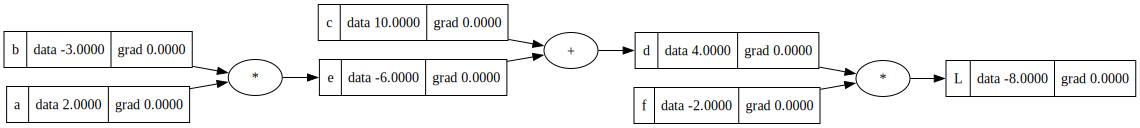

In [39]:
draw_dot(L)

dL/dL = 1

dL/dd = ? -> L = d * f -> dL/dd = f = -2

dL/df = ? -> L = d * f -> dL/df = d = 4

dL/dc = ? -> dL/dd * dd/dc = -2 * 1 = -2

dL/de = ? -> dL/dd * dd/de = -2 * 1 = -2

dL/da = ? -> dL/dd * dd/de * de/da = -2 * 1 * -3 = 6

dL/db = ? -> dL/dd * dd/de * de/db = -2 * 1 *  2 = -4

$$
\frac{\partial L}{\partial L} = 1
$$

$$
\frac{\partial L}{\partial d} = f = -2
\quad \text{where } L = d \cdot f
$$

$$
\frac{\partial L}{\partial f} = d = 4
\quad \text{where } L = d \cdot f
$$

$$
\frac{\partial L}{\partial c}
= \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial c}
= (-2)(1) = -2
$$

$$
\frac{\partial L}{\partial e}
= \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e}
= (-2)(1) = -2
$$

$$
\frac{\partial L}{\partial a}
= \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} \cdot \frac{\partial e}{\partial a}
= (-2)(1)(-3) = 6
$$

$$
\frac{\partial L}{\partial b}
= \frac{\partial L}{\partial d} \cdot \frac{\partial d}{\partial e} \cdot \frac{\partial e}{\partial b}
= (-2)(1)(2) = -4
$$

In [23]:
# staging area to avoid polluting the global scope
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data + h
    
    print((L2 - L1) / h)
    
lol() # dL/dL

0.9999999999621422


In [24]:
L.grad = 1.0

In [25]:
# staging area to avoid polluting the global scope
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c + Value(h); d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1) / h)
    
lol() # dL/dd

-1.9999999999242843


In [26]:
d.grad = -2

In [27]:
# staging area to avoid polluting the global scope
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0 + h, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1) / h)
    
lol() # dL/df

4.000000000026205


In [28]:
f.grad = 4

In [29]:
# staging area to avoid polluting the global scope
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10 + h, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1) / h)
    
lol() # dL/dc

-1.9999999999242843


In [30]:
c.grad = -2

In [31]:
# staging area to avoid polluting the global scope
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = (a * b) + Value(h); e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1) / h)
    
lol() # dL/de

-1.9999999999242843


In [32]:
e.grad = -2

In [33]:
b.grad, a.grad = -4, 6

In [34]:
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')   
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a') 
    a.data += h   
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = (a * b) ; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1) / h)
    
lol() # dL/da

6.000000000128124


In [35]:
def lol():
    
    h = 0.00001
    
    a = Value(2.0, label='a')   
    b = Value(-3.0, label='b')
    c = Value(10, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    # bump a by h
    a = Value(2.0, label='a')    
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10, label='c')
    e = (a * b) ; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data
    
    print((L2 - L1) / h)
    
lol() # dL/db

-4.000000000026205


## final computation graph

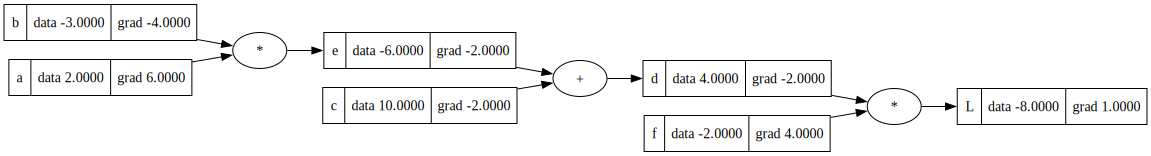

In [36]:
draw_dot(L)

# Increasing L
### now i wanna tweak the leaf nodes of L (children) to increase L

In [37]:
L._prev

{Value(data=-2.0), Value(data=4.0)}

In [38]:
L.data # before tweaking leaf nodes

-8.0

so now if i wanna increase L I have to go in the direction of the gradient of its leaf nodes

In [39]:
a.data += 0.01 * a.grad # small step in the direction of the gradient
b.data += 0.01 * b.grad
e.data += 0.01 * e.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
d.data += 0.01 * d.grad

In [40]:
# rerun the forward pass
e = a * b
d = e + c
L = d * f
L.data

-7.286496

# Backprop through a Neuron

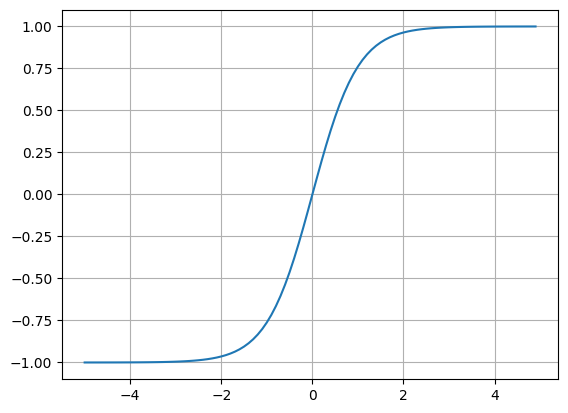

In [41]:
plt.plot(np.arange(-5,5,0.1), np.tanh(np.arange(-5,5,0.1)))
plt.grid()
plt.show()

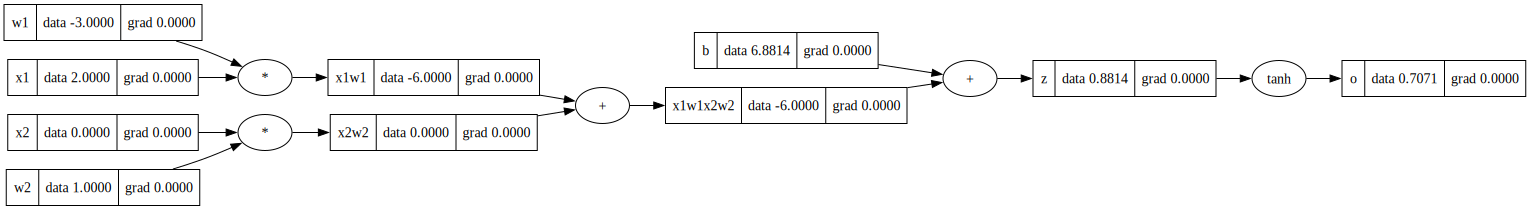

In [ ]:
# inputs x1, x2 -> 2 features
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2 -> how important these features are
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias -> how sensitive this neuron is
# how easy it is to activate the neuron
b  = Value(6.881376, label='b')

x1w1 = x1 * w1; x1w1.label='x1w1'
x2w2 = x2 * w2; x2w2.label='x2w2'
 
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'

z = x1w1x2w2 + b; z.label='z' # output of the neuron before activiation

# self is z
o = z.tanh() # activating z using tanh which was implemented in the Value class
o.label = 'o'
draw_dot(o)

## Manual backprop through the leaf nodes of the o (activated z)

do / do? -> 1

o = tanh(z) # just like the sigmoid derv, we have a conveient way of deriving tanh
do / dz -> 1 - (tanh(z))**2 = 1 - o**2

z = w1x1w2x2 + b (contant + var)
dz / db -> 1 
do / db = do / dz * dz / db = 0.5 * 1= 0.5

z = w1x1w2x2 + b (var + contsnt)
dz / dw1x1w2x2 -> 1
do / dw1x1w2x2 = do / dz * dz / dw1x1w2x2 = 0.5 * 1= 0.5

x1w1x2w2 = x1w1 + x2w2
dx1w1x2w2 / dx1w1 = 1
dx1w1x2w2 / dx2w2 = 1

do / dx1w1 = do/dz * dz/dw1x1w2x2 * ddw1x1w2x2/dw1x1 = 0.5
do / dx2w2 = do/dz * dz/dw1x1w2x2 * ddw1x1w2x2/dw2x2 = 0.5

x2w2 = x2 * w2
dx2w2 / dx2 = w2
dx2w2 / dw2 = x2




x1w1 = x1 * w1
dx1w1 / dx1 = w1
dx1w1 / dw1 = x1

In [43]:
o.data

np.float64(0.7071079876747176)

In [44]:
# grads
o.grad = 1
z.grad = 1 - (o.data)**2 # do/dz
b.grad = 0.5 # do/db
x1w1x2w2.grad = 0.5 # do/dw1x1w2x2
x1w1.grad = 0.5 # do / dx1w1
x2w2.grad = 0.5 # do / dx2w2
x1.grad =  w1.data * x1w1.grad
# do/dx1 = do/dz * dz/dw1x1w2x2 * dx1w1x2w2/dx1w1 * dx1w1/dx1
# do/dx1 = do/dx1w1 * dx1w1/dx1
w1.grad =  x1.data * x1w1.grad

x2.grad =  w2.data * x2w2.grad  
w2.grad =  x2.data * x2w2.grad  


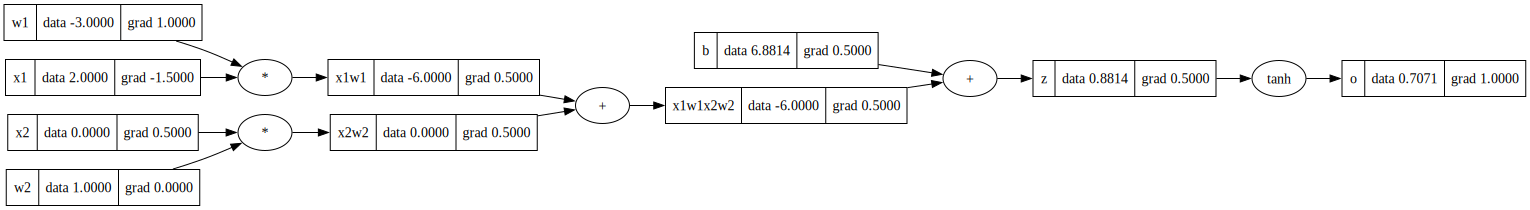

In [45]:
draw_dot(o)

In [46]:
def loll():
    
    # inputs x1, x2 -> 2 features
    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    # weights w1, w2 -> how important these features are
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    # bias -> how sensitive this neuron is
    # how easy it is to activate the neuron
    b  = Value(6.881376, label='b')

    x1w1 = x1 * w1; x1w1.label='x1w1'
    x2w2 = x2 * w2; x2w2.label='x2w2'
 
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'

    z = x1w1x2w2 + b; z.label='z' # output of the neuron before activiation

    o = z.tanh() # activating z using tanh which was implemented in the Value class
    o1=o.data

    ###
    
    h = 0.00001
    
    # inputs x1, x2 -> 2 features
    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    # weights w1, w2 -> how important these features are
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    # bias -> how sensitive this neuron is
    # how easy it is to activate the neuron
    b  = Value(6.881376+h, label='b')

    x1w1 = x1 * w1; x1w1.label='x1w1'
    x2w2 = x2 * w2; x2w2.label='x2w2'
 
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'

    z = x1w1x2w2 + b; z.label='z' # output of the neuron before activiation

    o = z.tanh()
    o2=o.data
    
    print((o2-o1)/h)
    
loll()


0.49999475822959377


# 🧠 Manual Backpropagation (Step-by-Step)

We compute gradients using the **chain rule**:

$$
\frac{\partial o}{\partial x} = \frac{\partial o}{\partial z} \cdot \frac{\partial z}{\partial x}
$$

---

## 🔁 1. Start at the output

$$
\frac{\partial o}{\partial o} = 1
$$

This is because any variable with respect to itself has derivative 1.

---

## 🔹 2. Activation function: $o = \tanh(z)$

The derivative of tanh is:

$$
\frac{\partial o}{\partial z} = 1 - \tanh^2(z)
$$

Since $o = \tanh(z)$, we rewrite:

$$
\frac{\partial o}{\partial z} = 1 - o^2
$$

---

## ➕ 3. Linear combination

$$
z = (x_1 w_1 + x_2 w_2) + b
$$

---

### 📌 Derivative w.r.t. $b$

$$
\frac{\partial z}{\partial b} = 1
$$

Now apply chain rule:

$$
\frac{\partial o}{\partial b}
=
\frac{\partial o}{\partial z} \cdot \frac{\partial z}{\partial b}
=
(1 - o^2)\cdot 1
$$

If $1 - o^2 = 0.5$:

$$
\frac{\partial o}{\partial b} = 0.5
$$

---

### 📌 Derivative w.r.t. $(x_1 w_1 + x_2 w_2)$

$$
\frac{\partial z}{\partial (x_1 w_1 + x_2 w_2)} = 1
$$

So:

$$
\frac{\partial o}{\partial (x_1 w_1 + x_2 w_2)} = 0.5
$$

---

## ➕ 4. Splitting the addition

$$
x_1 w_1 + x_2 w_2
$$

$$
\frac{\partial (x_1 w_1 + x_2 w_2)}{\partial (x_1 w_1)} = 1
$$

$$
\frac{\partial (x_1 w_1 + x_2 w_2)}{\partial (x_2 w_2)} = 1
$$

So:

$$
\frac{\partial o}{\partial (x_1 w_1)} = 0.5
$$

$$
\frac{\partial o}{\partial (x_2 w_2)} = 0.5
$$

---

## ✖️ 5. Product nodes

### For $x_2 w_2 = x_2 \cdot w_2$

$$
\frac{\partial (x_2 w_2)}{\partial x_2} = w_2
$$

$$
\frac{\partial (x_2 w_2)}{\partial w_2} = x_2
$$

Apply chain rule:

$$
\frac{\partial o}{\partial x_2}
=
\frac{\partial o}{\partial (x_2 w_2)} \cdot \frac{\partial (x_2 w_2)}{\partial x_2}
=
0.5 \cdot w_2
$$

$$
\frac{\partial o}{\partial w_2}
=
\frac{\partial o}{\partial (x_2 w_2)} \cdot \frac{\partial (x_2 w_2)}{\partial w_2}
=
0.5 \cdot x_2
$$

---

### For $x_1 w_1 = x_1 \cdot w_1$

$$
\frac{\partial (x_1 w_1)}{\partial x_1} = w_1
$$

$$
\frac{\partial (x_1 w_1)}{\partial w_1} = x_1
$$

Apply chain rule:

$$
\frac{\partial o}{\partial x_1} = 0.5 \cdot w_1
$$

$$
\frac{\partial o}{\partial w_1} = 0.5 \cdot x_1
$$

---

## 🎯 Final Gradients

$$
\frac{\partial o}{\partial b} = 0.5
$$

$$
\frac{\partial o}{\partial w_1} = 0.5 x_1, \quad
\frac{\partial o}{\partial w_2} = 0.5 x_2
$$

$$
\frac{\partial o}{\partial x_1} = 0.5 w_1, \quad
\frac{\partial o}{\partial x_2} = 0.5 w_2
$$

---

## 🧠 Key Rules

- Addition → gradient passes unchanged  
- Multiplication → multiply by the other variable  
- Chain rule → multiply along the path  
- $\tanh'(z) = 1 - o^2$

---


In [4]:
import numpy as np

# children, op, and label are optianl params
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # stores the gradient of L with respect to this value object
        self._backward = lambda: None # base case for a leaf node in the graph (a node that is not the result of an operation)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def __add__(self, other):
        # out = self + other
        
        # this line allows us to do a + 3, or b+1 by wrapping the int in value class
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        # a local derivative is defined as the derv of the output of an operation with respect to its inputs. 
        # It is local because it only depends on the inputs and outputs of the operation and not on the rest of the graph. 
        # It is a property of the operation itself and does not depend on how the operation is used in the graph. It is a building block for backpropagation because it allows us to compute the gradient of the final output with respect to any input by chaining together the local derivatives along the path from the input to the output.
        # local dervitive of out with respect to self and other is 1 since dout/dself = 1 and dout/dother = 1
        def _backward():
            #local derv * global derv
            self.grad  += 1.0 * out.grad # out.grad is the derv of the final output of the neuron wrt out
            other.grad += 1.0 * out.grad
        
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
    # out = self * other
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        # in the expression -> out = self * other
        # local dervitive of out with respect to self and other is dout/dself = other.data and dout/dother = self.data
        def _backward():
            self.grad  += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # allow us to do 2 * a by rearranging it to a * 2
        return self * other
    
    def expo(self):
        x = self.data
        out = Value(np.exp(x), (self, ), 'exp')
        # a python closure
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __truediv__(self, other): # self/other
        return self * other**-1
    
    def __pow__(self, other): # self**other
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self,), 'f**{other}')
        def _backward():
            self.grad += other * out.grad * self.data**(other-1)
        out._backward = _backward
        return out
    
    # o is a resuklt of a tanh so when we call o._backward()
    def tanh(self):
    # out = tanh(self)
    # defining the local derivative of tanh with respect to its input self
    # dout/dself = 1 - tanh^2 = 1 - out.data^2
        x = self.data
        t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
        def _backward(): #local d  * global d
            self.grad += (1 - t**2) * out.grad # out.grad is chained (backpropped) to z.grad thru the local derv of tanh (1-tanh^2)
        out._backward = _backward
        return out
    
    def backward(self):
        
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

In [7]:
x1

Value(data=2.0, label=x1)

In [6]:
# inputs x1, x2 -> 2 features
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2 -> how important these features are
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias -> how sensitive this neuron is
# how easy it is to activate the neuron
b  = Value(6.881376, label='b')

x1w1 = x1 * w1; x1w1.label='x1w1'
x2w2 = x2 * w2; x2w2.label='x2w2'
 
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'

z = x1w1x2w2 + b; z.label='z' # output of the neuron before activiation

# self is z
o = z.tanh() # activating z using tanh which was implemented in the Value class
o.label = 'o'
draw_dot(o)

NameError: name 'draw_dot' is not defined

In [20]:
o.backward()

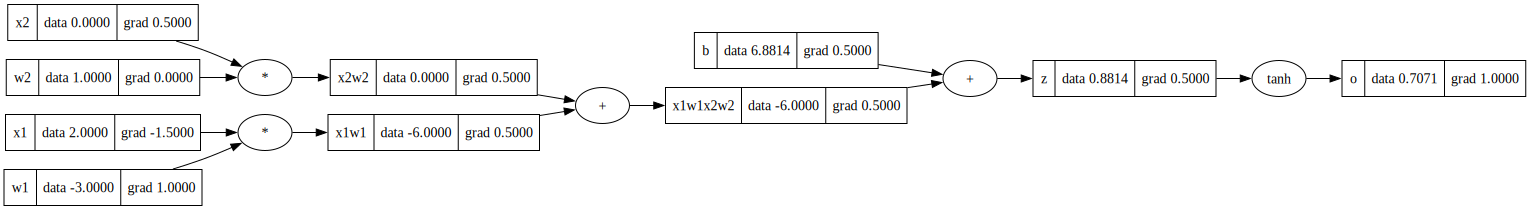

In [21]:
draw_dot(o)

In [63]:
o.grad = 1.0

o._backward()

In [65]:
z._backward()

In [67]:
x1w1x2w2._backward()

In [69]:
x1w1._backward()

In [71]:
x2w2._backward()

In [ ]:
b._backward() # backproping to the bias node which is a leaf node in the graph so it has no local derv and its grad is only the global derv which is 0.5 in this case since do/db = 0.5
# this is the base case for a leaf node in the value class

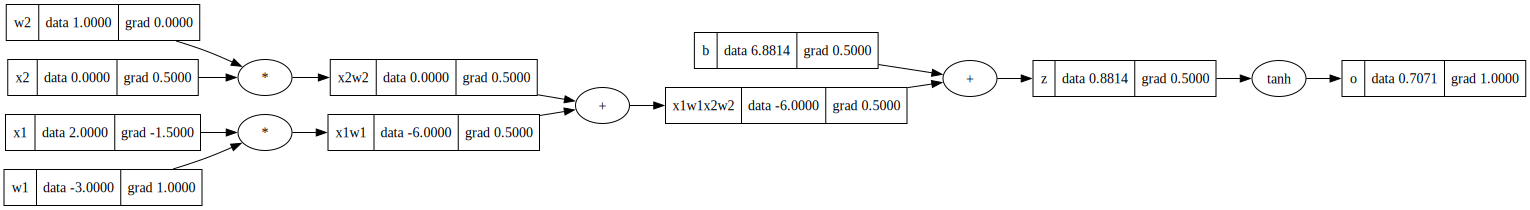

In [72]:
draw_dot(o)

do/do = o.grad = 1
o = tanh(z) -> z.tanh()

the grad is gonna flow from the o node to the z node, passing thru the tanh. o.grad is thus chained to z.grad thru the local derv do/dz
do/dz = 1 - o**2 = 1 - 0.5 = 0.5

now the grad from z (z.grad) flows back thru the + op to self and other



In [ ]:
# now we need to build a topological order of the nodes in the graph 
# so that we can call the _backward() method on each node in the correct order. 
# We can do this by performing a depth first search on the graph and adding the nodes to a list as we visit them. 
# Then we can reverse the list to get the correct order for backpropagation.

In [77]:
topo = []

visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o) 
topo

[Value(data=6.881376, label=b),
 Value(data=0.0, label=x2),
 Value(data=1.0, label=w2),
 Value(data=0.0, label=x2w2),
 Value(data=2.0, label=x1),
 Value(data=-3.0, label=w1),
 Value(data=-6.0, label=x1w1),
 Value(data=-6.0, label=x1w1x2w2),
 Value(data=0.8813760000000004, label=z),
 Value(data=0.7071079876747176, label=o)]

In [73]:
o._prev

{Value(data=0.8813760000000004)}

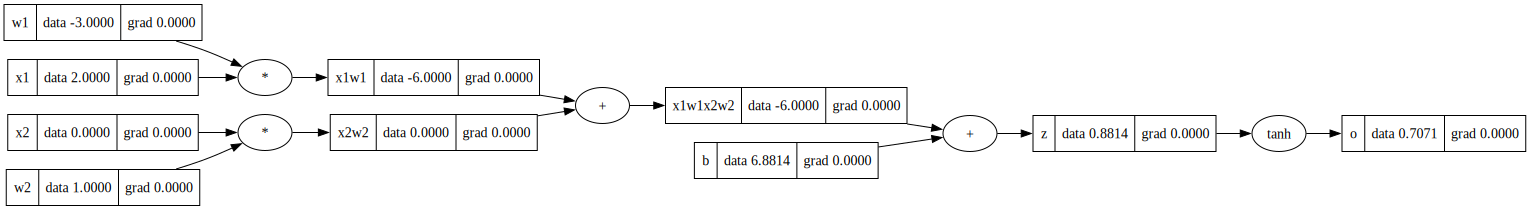

In [79]:
draw_dot(o)

In [ ]:
def backward():
    o.grad = 1.0
    
    topo = []
    visited = set()
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
            
    for node in reversed(topo):
        node._backward()

In [83]:
o.backward()

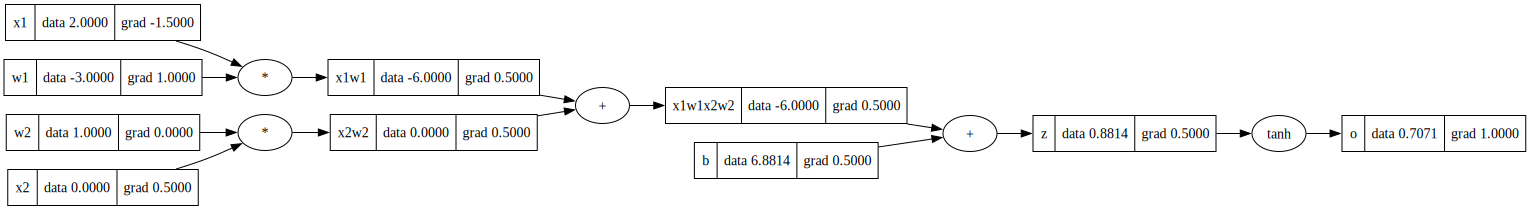

In [84]:
draw_dot(o)

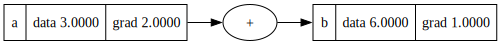

In [22]:
a = Value(3.0, label='a')
b = a + a
b.label = 'b'

b.backward()
draw_dot(b)

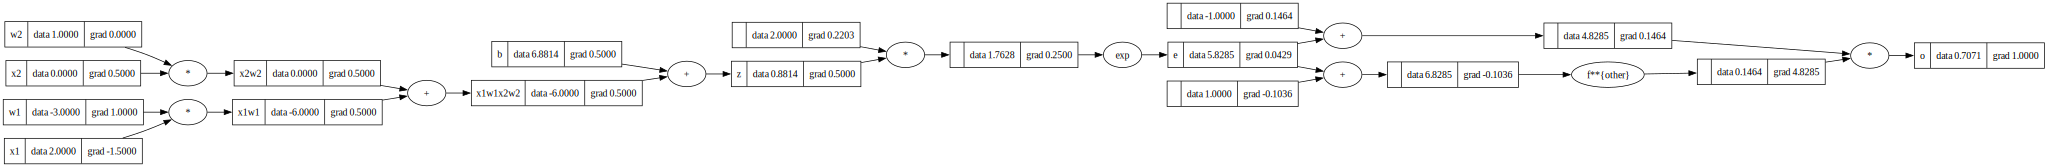

In [24]:
# inputs x1, x2 -> 2 features
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2 -> how important these features are
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias -> how sensitive this neuron is
# how easy it is to activate the neuron
b  = Value(6.881376, label='b')

x1w1 = x1 * w1; x1w1.label='x1w1'
x2w2 = x2 * w2; x2w2.label='x2w2'
 
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1x2w2'

z = x1w1x2w2 + b; z.label='z' # output of the neuron before activiation

# self is z
# x = self.data
# t = (np.exp(2*x) - 1) / (np.exp(2*x) + 1)

e = (2*z).expo(); e.label = 'e'
o = (e - 1 ) / (e + 1); o.label = 'o'

o.backward()
draw_dot(o)

In [ ]:
a = Value(2.0, label='a')
b = a + a; b.label = 'b'

# PyTorch

In [40]:
import torch

In [47]:
x1 = torch.Tensor([2.0]).double()      ;   x1.requires_grad=True
x2 = torch.Tensor([0.0]).double()      ;   x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double()     ;   w1.requires_grad=True
w2 = torch.Tensor([1.0]).double()      ;   w2.requires_grad=True
b  = torch.Tensor([6.88137]).double()  ;   b.requires_grad=True

z = x1*w1 + x2*w2 + b
o = torch.tanh(z)

print(o.data.item())

o.backward() # computes the gradients of o with respect to all the leaf nodes in the graph (x1, x2, w1, w2, b) and stores them in the .grad attribute of each node

print('############# GRADIENTS ############')
print(x1.grad.item())
print(w1.grad.item())   
print(x2.grad.item())
print(w2.grad.item())
print(b.grad.item())

0.7071050214706146
############# GRADIENTS ############
-1.500007465833125
1.0000049772220834
0.5000024886110417
0.0
0.5000024886110417


In [46]:
x1.shape

torch.Size([1])

In [48]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [49]:
w1.grad

tensor([1.0000], dtype=torch.float64)

# Building Neural Nets

In [ ]:
class Neuron:
  # the neuron has to know the number of inputs it is expecting so that it can create the appropriate number of weights and a bias term
  def __init__(self, nin):
    self.w = [Value(np.random.uniform(-1, 1)) for _ in range(nin)]
    self.b = Value(np.random.uniform(-1, 1))
  
  def __call__(self, x):
    # implement the forward pass
    # z = w @ x + b
    z = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = z.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b] # list of all the parameters in the neuron (weights and bias)
  
  
class Layer:
  # nin is the number of inputs to the layer and nout is the number of neurons in the layer
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
  
  

class myMLP:
  def __init__(self, nin, nouts): # outs is a list that contains the size of each layer
    sz = [nin] + nouts # contcating the 2 lists
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]
        
          

In [19]:
x = [2.1]
n = Neuron(len(x))
n(x)

Value(data=-0.33752201870405196, label=)

In [20]:
n.parameters()

[Value(data=0.2924004896358847, label=),
 Value(data=-0.9653343380797419, label=)]

In [ ]:
x = [2.1]

l = Layer(len(x), 3)
l1_out = l(x)

[Value(data=0.9170887843501087, label=),
 Value(data=0.7352312105237515, label=),
 Value(data=0.9836226654844213, label=)]

In [15]:
l.parameters()

[Value(data=0.05510592059026087, label=),
 Value(data=0.32590818836511204, label=),
 Value(data=0.1236363686080546, label=),
 Value(data=-0.8359094676400611, label=),
 Value(data=0.33944121268154714, label=),
 Value(data=-0.7571340904732067, label=)]

In [16]:
x = [2.1]

# forward pass
model = myMLP(len(x), [3,3,1])
model(x)

Value(data=-0.8006616715364745, label=)

In [18]:
len(model.parameters())

22

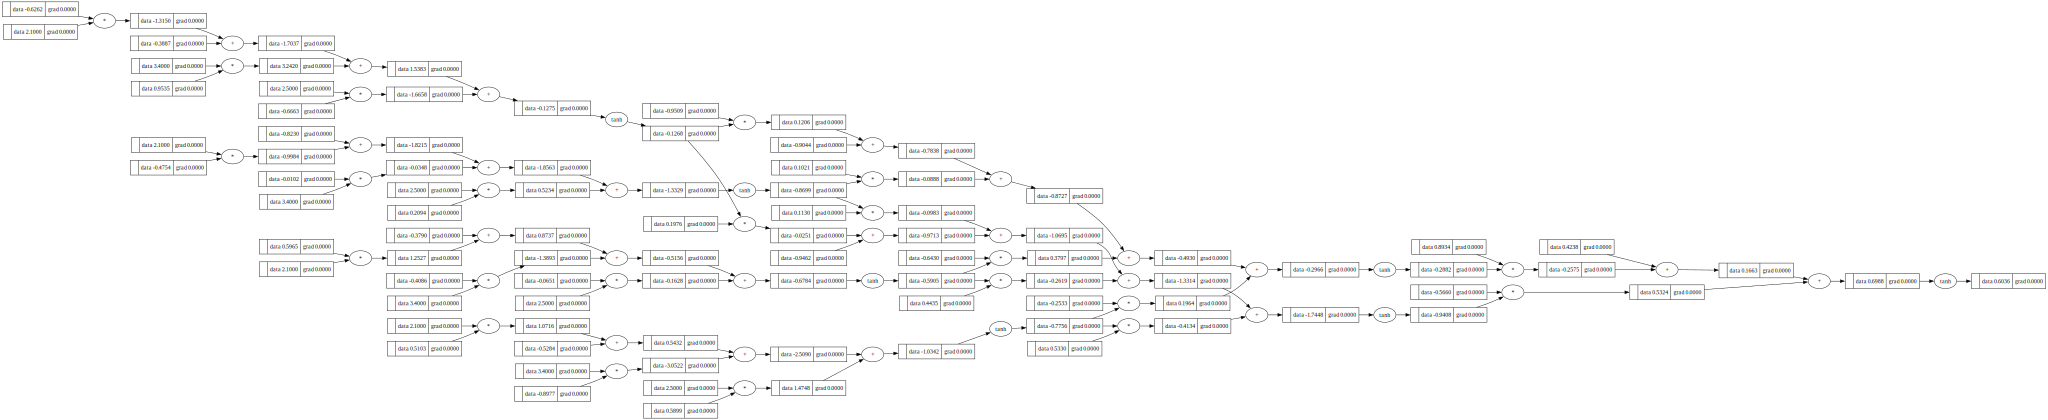

In [99]:
draw_dot(model(x))

In [103]:
import random

In [ ]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]



class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [105]:
model = MLP(3, [4,4,1])
model(x)

Value(data=-0.5501419383671445, label=)

In [128]:
# dummy data to test on
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [Value(1.0), Value(-1.0), Value(-1.0), Value(1.0)] # desired targets

In [129]:
# forawrd pass
yhat = [model(x) for x in xs]
# yhat = [yhat[i].data for i in range(len(yhat))]

In [131]:
loss = np.sum([(yi - yhi)**2 for yi, yhi in zip(ys, yhat)])

In [134]:
loss.backward()

In [140]:
model.parameters()[0].data # w1 of the first neuron in the first layer

-0.2571271248326281

In [139]:
model.layers[0].neurons[0].w[0].data # w1 of the first neuron in the first layer

-0.2571271248326281

In [ ]:
# positive gradient means if we   w1.data, the loss will increase so we want to decrease w1 to minimize the loss
model.layers[0].neurons[0].w[0].grad # w1 of the first neuron in the first layer

np.float64(0.26735634843065637)

In [143]:
model.parameters()[1].data # w1 of the first neuron in the first layer

0.5718905307323123

In [144]:
model.parameters()[1].grad # w1 of the first neuron in the first layer

np.float64(0.18361657105749718)

In [145]:
model.parameters()[5].data # w1 of the first neuron in the first layer

-0.6831987234176087

In [146]:
model.parameters()[5].grad # w1 of the first neuron in the first layer

np.float64(-0.35965442455814395)

In [142]:
len(model.parameters())

41

In [147]:
for p in model.parameters():
    p.data += -0.01 * p.grad

In [148]:
model.parameters()[0].data # w1 of the first neuron in the first layer

np.float64(-0.2598006883169347)

In [149]:
model.parameters()[1].data # w1 of the first neuron in the first layer

np.float64(0.5700543650217373)

In [151]:
yhat = [model(x) for x in xs]

# new loss
loss = np.sum([(yi - yhi)**2 for yi, yhi in zip(ys, yhat)])
loss

Value(data=5.18046097577227, label=)

In [159]:
epochs = 100

for epoch in range(epochs):
    # forward pass
    yhat = [model(x) for x in xs]
    loss = np.sum([(yi - yhi)**2 for yi, yhi in zip(ys, yhat)])
    
    # flush out all the gradients from the first backward pass
    for p in model.parameters():
        p.grad = 0.0
        
    # backward pass
    loss.backward() # finds all the gradients of loss wrt all params
    
    # update params - gradient descent
    for p in model.parameters():
        p.data += -0.01 * p.grad
        
    print(epoch, loss.data)


0 0.008429007796170559
1 0.008403478042704013
2 0.00837809490672301
3 0.008352857157109747
4 0.00832776357630469
5 0.008302812960122315
6 0.008278004117569494
7 0.008253335870667365
8 0.008228807054275259
9 0.008204416515918314
10 0.008180163115617093
11 0.008156045725720462
12 0.008132063230740949
13 0.008108214527192488
14 0.008084498523431231
15 0.008060914139498297
16 0.008037460306965382
17 0.008014135968782858
18 0.007990940079129849
19 0.007967871603267025
20 0.007944929517391553
21 0.007922112808494253
22 0.007899420474219135
23 0.007876851522724862
24 0.007854404972548593
25 0.007832079852471831
26 0.00780987520138828
27 0.007787790068173813
28 0.007765823511558377
29 0.007743974599999854
30 0.007722242411559796
31 0.0077006260337812975
32 0.00767912456356829
33 0.007657737107067002
34 0.007636462779549168
35 0.007615300705296733
36 0.00759425001748865
37 0.007573309858089104
38 0.0075524793777375695
39 0.007531757735640272
40 0.007511144099463634
41 0.007490637645228944
42 0.

In [161]:
yhat

[Value(data=0.9704214427752949, label=),
 Value(data=-0.9835652796211946, label=),
 Value(data=-0.9511726078683107, label=),
 Value(data=0.9458601641039371, label=)]

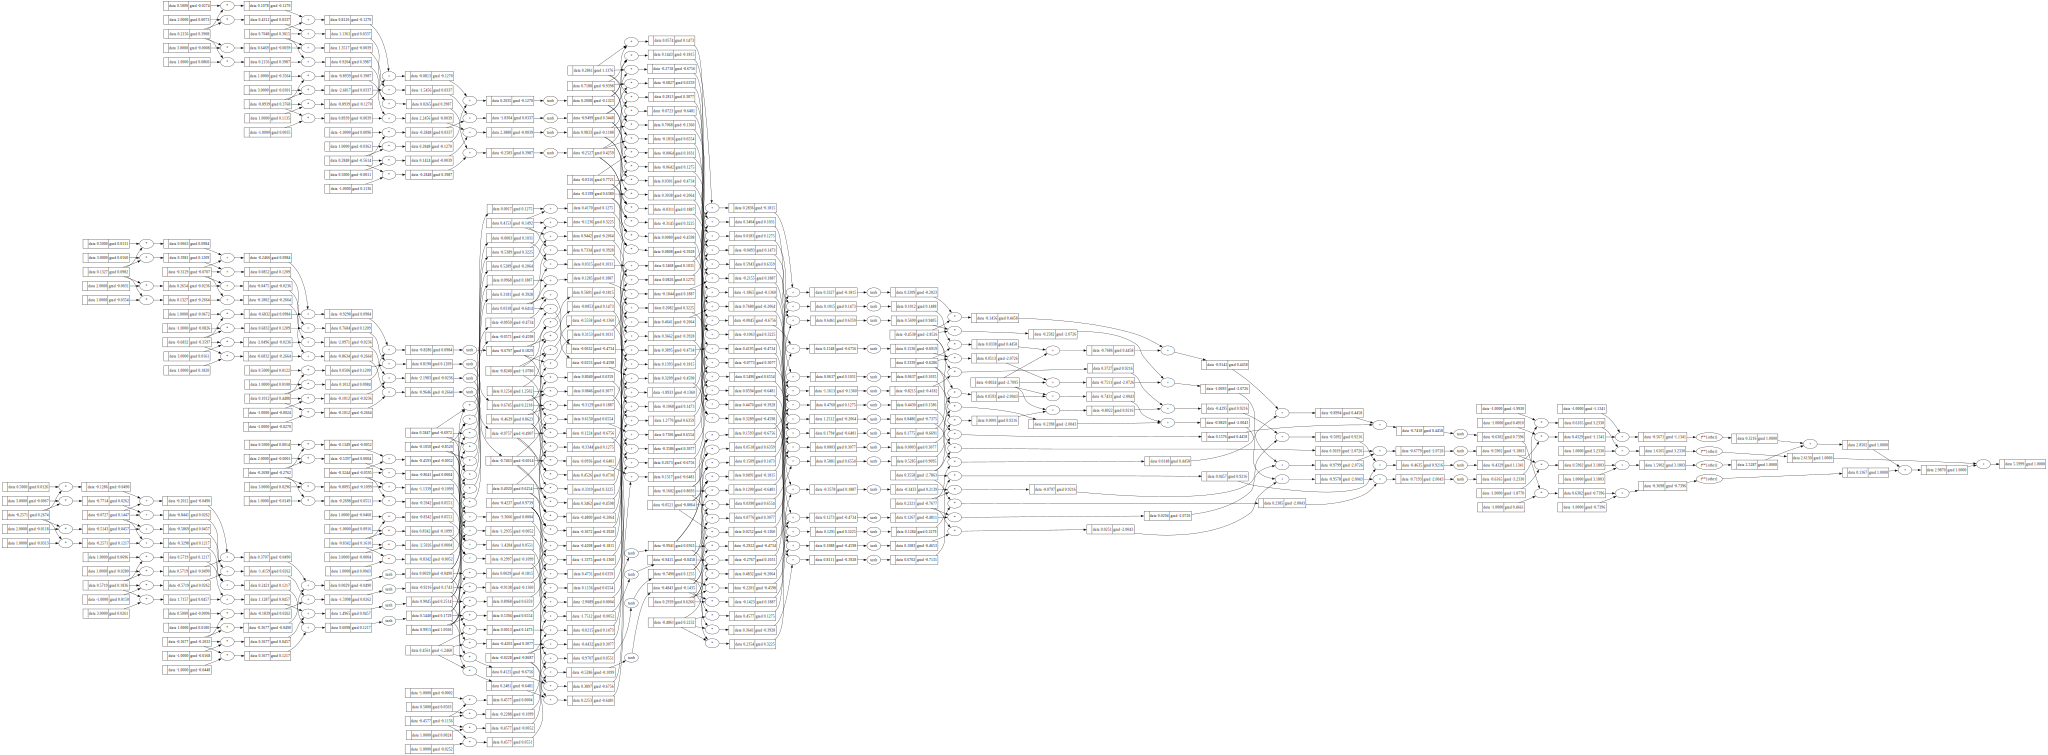

In [135]:
draw_dot(loss)

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [23]:
class mySimpleMLP(torch.nn.Module):
    def __init__(self, nin, nouts):
        super().__init__()
        sz = [nin] + nouts
        self.layers = nn.ModuleList([nn.Linear(sz[i], sz[i+1]) for i in range(len(nouts))])
        
    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return x

In [24]:
x = torch.tensor([2.0])

In [42]:
model = mySimpleMLP(1, [5,5,1])
model(x)

tensor([0.0663], grad_fn=<ReluBackward0>)

In [43]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.9593],
         [-0.8345],
         [-0.4571],
         [ 0.6672],
         [ 0.9068]], requires_grad=True),
 Parameter containing:
 tensor([ 0.7204, -0.1501,  0.4511, -0.8381,  0.4657], requires_grad=True),
 Parameter containing:
 tensor([[-0.2561, -0.0834, -0.3348,  0.0139, -0.2487],
         [ 0.1371,  0.2701, -0.2408, -0.0458, -0.1502],
         [ 0.4091, -0.1218,  0.2136, -0.3868, -0.2159],
         [ 0.4092, -0.2179,  0.2597, -0.0336,  0.1933],
         [ 0.3448,  0.4021,  0.3555,  0.2927, -0.4013]], requires_grad=True),
 Parameter containing:
 tensor([0.1734, 0.1419, 0.0150, 0.0827, 0.3084], requires_grad=True),
 Parameter containing:
 tensor([[-0.3125, -0.3791, -0.3837, -0.0128, -0.3015]], requires_grad=True),
 Parameter containing:
 tensor([0.4321], requires_grad=True)]

In [39]:
model.layers[0].bias.shape

torch.Size([5])

In [35]:
model.layers[0].weight

Parameter containing:
tensor([[-0.1318],
        [ 0.3795],
        [-0.0623]], requires_grad=True)

In [40]:
model.layers[1].weight.shape

torch.Size([5, 5])

In [41]:
model.layers[1].bias.shape

torch.Size([5])